# Decision Task

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model import RateRNN, RateRNN_torch
from decision_task import GoCueDecisionTask
import torch

%load_ext autoreload
%autoreload 2

# check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [2]:
import sys
import torch

print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if hasattr(torch.version, 'cuda'):
    print(f"PyTorch CUDA binary version: {torch.version.cuda}")
else:
    print("PyTorch CUDA binary version: None (CPU-only build installed)")

try:
    import subprocess
    smi = subprocess.check_output("nvidia-smi", shell=True).decode()
    print("\nnvidia-smi status: WORKING")
except Exception:
    print("\nnvidia-smi status: FAILED (Driver issue or no NVIDIA GPU detected)")

Python version: 3.13.11
PyTorch version: 2.13.0+cpu
CUDA available: False
PyTorch CUDA binary version: None

nvidia-smi status: FAILED (Driver issue or no NVIDIA GPU detected)


### Basic numpy model without learning

(100, 1000)


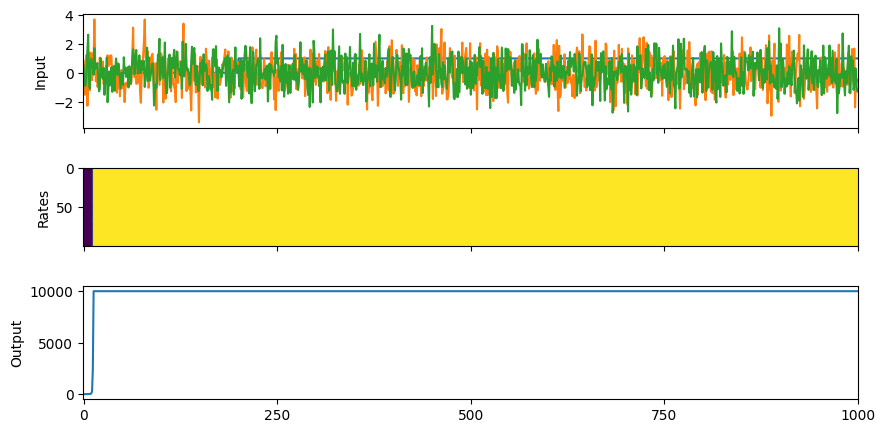

In [3]:
n_neurons = 100
time_steps = 1000
noise_level = 0.05
# Input of 3 channels to all neurons
n_channels = 3 # 2 decisions, 1 go cue
n_output = 1    
rnn = RateRNN(n_neurons, g=1.50, frac_e=0.1, input_dim=n_channels, output_dim=n_output)
# input = np.random.randn(n_channels, time_steps)
go_cue = np.zeros((1, time_steps))
go_cue[0, 200:] = 1

input = np.concatenate([go_cue, np.random.randn(n_channels-1, time_steps)], axis=0)
r_hist, x_hist, output_matrix = rnn.simulate(time_steps = time_steps, input_matrix = input, noise_level = noise_level)
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10, 5))

axs[0].plot(input.T)
axs[1].imshow(r_hist.T)
axs[2].plot(output_matrix)
axs[0].set_ylabel('Input')
axs[1].set_ylabel('Rates')
axs[2].set_ylabel('Output')
axs[1].set_xticks(np.linspace(0, time_steps, 5))
# plt.colorbar()
plt.show()

coherence=0.2, cumulative evidence=6.90, target=+1
activity: sat=0.00, silent=1.00, rate_mean=0.08


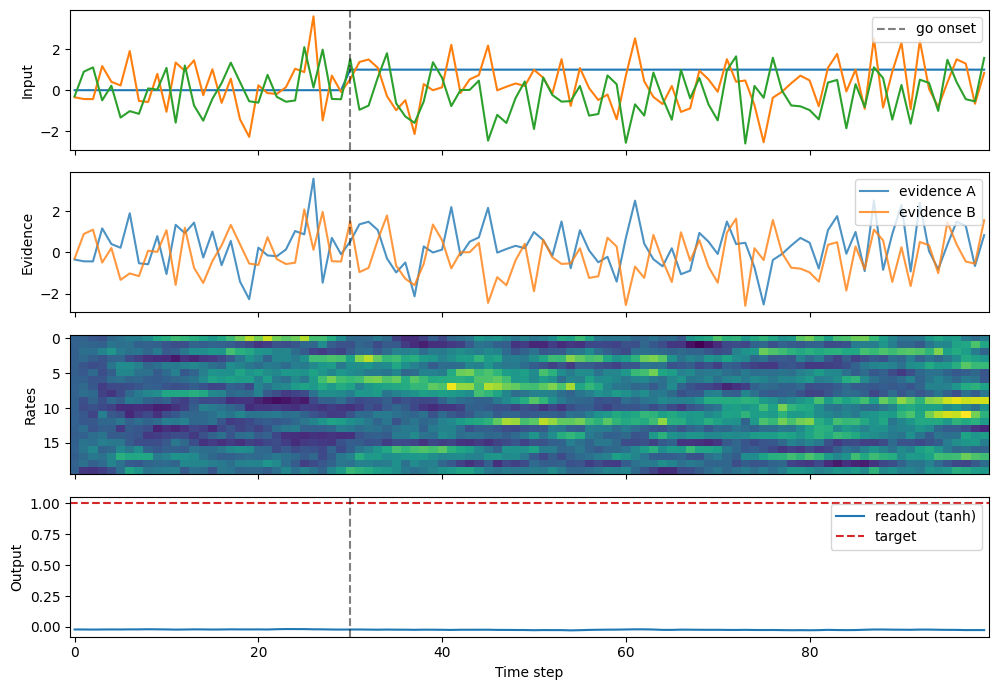

In [20]:
# Go-cue-gated decision task (PyTorch + BPTT)
torch.manual_seed(0)

n_neurons = 20
time_steps = 100
go_onset = 30
noise_level = 0.05
coherence = 0.2
n_channels = 3
n_output = 1

task = GoCueDecisionTask(go_onset=go_onset)
rnn_torch = RateRNN_torch(
    n_neurons,
    g=1.5,
    frac_e=0.8,
    input_dim=n_channels,
    output_dim=n_output,
).to(device)

trial_input, trial_target = task.sample_trial(
    time_steps,
    coherence=coherence,
    device=device,
)

ch_a, ch_b = task.decision_channels
cum_evidence = trial_input[ch_a, :go_onset].sum() - trial_input[ch_b, :go_onset].sum()
print(f"coherence={coherence}, cumulative evidence={cum_evidence.item():.2f}, target={trial_target.item():+.0f}")

with torch.no_grad():
    r_hist, x_hist, output_matrix = rnn_torch.simulate(trial_input.unsqueeze(0), noise_level=noise_level)
    stats = rnn_torch.activity_stats(r_hist, x_hist)
print(f"activity: sat={stats['frac_saturated']:.2f}, silent={stats['frac_silent']:.2f}, rate_mean={stats['rate_mean']:.2f}")

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 7))
axs[0].plot(trial_input.cpu().T)
axs[0].axvline(go_onset, color='k', ls='--', alpha=0.5, label='go onset')
axs[0].set_ylabel('Input')
axs[0].legend(loc='upper right')

axs[1].plot(trial_input[ch_a].cpu(), label='evidence A', alpha=0.8)
axs[1].plot(trial_input[ch_b].cpu(), label='evidence B', alpha=0.8)
axs[1].axvline(go_onset, color='k', ls='--', alpha=0.5)
axs[1].set_ylabel('Evidence')
axs[1].legend(loc='upper right')

axs[2].imshow(r_hist.squeeze(0).T.cpu().numpy(), aspect='auto')
axs[2].set_ylabel('Rates')

axs[3].plot(output_matrix.squeeze(0).squeeze(-1).cpu(), label='readout (tanh)')
axs[3].axhline(trial_target.item(), color='C3', ls='--', label='target')
axs[3].axvline(go_onset, color='k', ls='--', alpha=0.5)
axs[3].set_ylabel('Output')
axs[3].set_xlabel('Time step')
axs[3].legend(loc='upper right')
plt.tight_layout()
plt.show()


epoch    1 | loss 1.0038 | accuracy 0.469 | coh 0.250 | sat 0.00 | silent 1.00
epoch   25 | loss 0.9928 | accuracy 0.594 | coh 0.248 | sat 0.00 | silent 1.00
epoch   50 | loss 0.9980 | accuracy 0.469 | coh 0.245 | sat 0.00 | silent 1.00
epoch   75 | loss 0.9886 | accuracy 0.562 | coh 0.243 | sat 0.00 | silent 1.00
epoch  100 | loss 0.9712 | accuracy 0.625 | coh 0.240 | sat 0.00 | silent 1.00
epoch  125 | loss 0.9809 | accuracy 0.531 | coh 0.238 | sat 0.00 | silent 1.00
epoch  150 | loss 0.9810 | accuracy 0.469 | coh 0.235 | sat 0.00 | silent 1.00
epoch  175 | loss 0.9500 | accuracy 0.688 | coh 0.233 | sat 0.00 | silent 1.00
epoch  200 | loss 0.9491 | accuracy 0.688 | coh 0.230 | sat 0.00 | silent 1.00
epoch  225 | loss 0.9098 | accuracy 0.969 | coh 0.228 | sat 0.00 | silent 1.00
epoch  250 | loss 0.8974 | accuracy 0.906 | coh 0.225 | sat 0.00 | silent 1.00
epoch  275 | loss 0.8532 | accuracy 0.938 | coh 0.223 | sat 0.00 | silent 1.00
epoch  300 | loss 0.7802 | accuracy 0.938 | coh 0.22

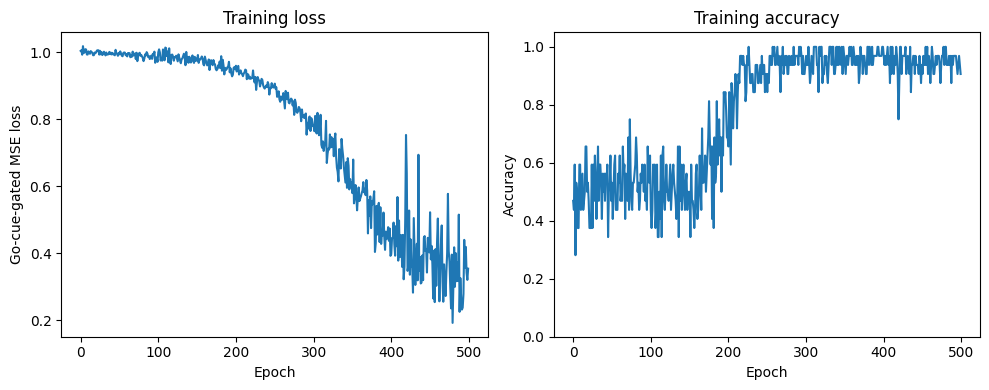

In [21]:
# Train on the decision task via BPTT
history = task.train(
    rnn_torch,
    n_epochs=500,
    batch_size=32,
    time_steps=time_steps,
    coherence=coherence,
    lr=1e-3,
    noise_level=noise_level,
    log_every=25,
)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(history['loss'])
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Go-cue-gated MSE loss')
axs[0].set_title('Training loss')

axs[1].plot(history['accuracy'])
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim(0, 1.05)
axs[1].set_title('Training accuracy')
plt.tight_layout()
plt.show()


Evaluation accuracy at coherence=0.2: 0.950


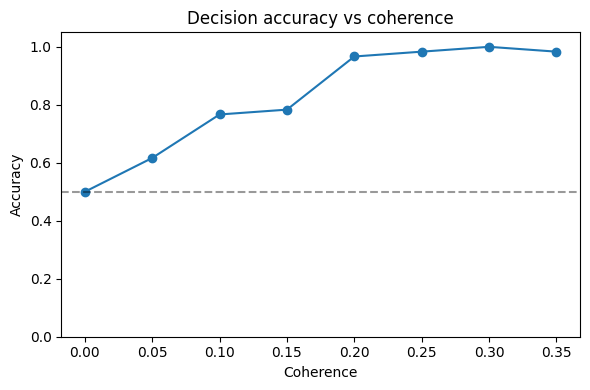

In [22]:
# Evaluate trained network on held-out trials and coherence sweep
n_eval = 80
eval_input, eval_target = task.sample_batch(
    n_eval,
    time_steps,
    coherence=coherence,
    device=device,
)

with torch.no_grad():
    _, _, eval_output = rnn_torch.simulate(eval_input, noise_level=0.0)

go_mask = task.go_mask(eval_input)
preds, _ = task.trial_predictions(eval_output, go_mask)
eval_accuracy = (preds == eval_target).float().mean().item()
print(f'Evaluation accuracy at coherence={coherence}: {eval_accuracy:.3f}')

coherences = np.linspace(0.0, 0.35, 8)
acc_by_coh = task.evaluate_coherence_sweep(
    rnn_torch,
    coherences,
    n_trials=60,
    time_steps=time_steps,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coherences, acc_by_coh, 'o-')
ax.axhline(0.5, color='k', ls='--', alpha=0.4)
ax.set_xlabel('Coherence')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Decision accuracy vs coherence')
plt.tight_layout()
plt.show()


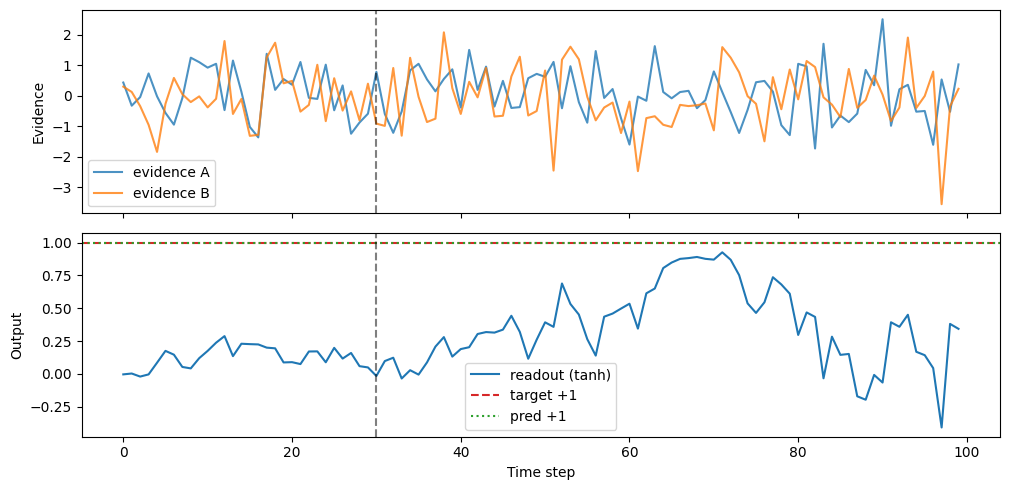

In [23]:
# Visualize one trained trial
demo_input, demo_target = task.sample_trial(
    time_steps,
    coherence=coherence,
    device=device,
)

with torch.no_grad():
    _, _, demo_out = rnn_torch.simulate(demo_input.unsqueeze(0), noise_level=0.0)

demo_out = demo_out.squeeze(0).squeeze(-1).cpu()
go_mask = task.go_mask(demo_input).unsqueeze(0)
pred, _ = task.trial_predictions(demo_out.unsqueeze(0), go_mask)
final_pred = pred.item()

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
axs[0].plot(demo_input[task.decision_channels[0]].cpu(), alpha=0.8, label='evidence A')
axs[0].plot(demo_input[task.decision_channels[1]].cpu(), alpha=0.8, label='evidence B')
axs[0].axvline(go_onset, color='k', ls='--', alpha=0.5)
axs[0].set_ylabel('Evidence')
axs[0].legend()

axs[1].plot(demo_out, label='readout (tanh)')
axs[1].axhline(demo_target.item(), color='C3', ls='--', label=f'target {demo_target.item():+.0f}')
axs[1].axhline(final_pred, color='C2', ls=':', label=f'pred {final_pred:+.0f}')
axs[1].axvline(go_onset, color='k', ls='--', alpha=0.5)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Output')
axs[1].legend()
plt.tight_layout()
plt.show()


coherence=0.2, cumulative evidence=6.05, target=+1
activity: sat=0.00, silent=1.00, rate_mean=0.29


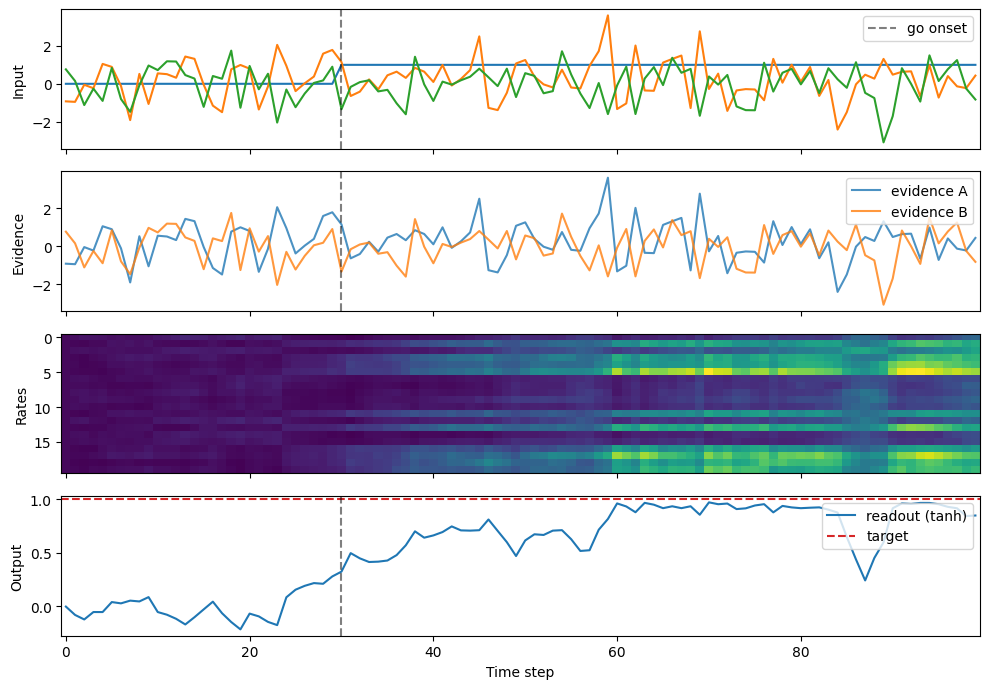

In [24]:
# Go-cue-gated decision task (PyTorch + BPTT)
torch.manual_seed(0)

n_neurons = 20
time_steps = 100
go_onset = 30
noise_level = 0.05
coherence = 0.2
n_channels = 3
n_output = 1

task = GoCueDecisionTask(go_onset=go_onset)

trial_input, trial_target = task.sample_trial(
    time_steps,
    coherence=coherence,
    device=device,
)

ch_a, ch_b = task.decision_channels
cum_evidence = trial_input[ch_a, :go_onset].sum() - trial_input[ch_b, :go_onset].sum()
print(f"coherence={coherence}, cumulative evidence={cum_evidence.item():.2f}, target={trial_target.item():+.0f}")

with torch.no_grad():
    r_hist, x_hist, output_matrix = rnn_torch.simulate(trial_input.unsqueeze(0), noise_level=noise_level)
    stats = rnn_torch.activity_stats(r_hist, x_hist)
print(f"activity: sat={stats['frac_saturated']:.2f}, silent={stats['frac_silent']:.2f}, rate_mean={stats['rate_mean']:.2f}")

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 7))
axs[0].plot(trial_input.cpu().T)
axs[0].axvline(go_onset, color='k', ls='--', alpha=0.5, label='go onset')
axs[0].set_ylabel('Input')
axs[0].legend(loc='upper right')

axs[1].plot(trial_input[ch_a].cpu(), label='evidence A', alpha=0.8)
axs[1].plot(trial_input[ch_b].cpu(), label='evidence B', alpha=0.8)
axs[1].axvline(go_onset, color='k', ls='--', alpha=0.5)
axs[1].set_ylabel('Evidence')
axs[1].legend(loc='upper right')

axs[2].imshow(r_hist.squeeze(0).T.cpu().numpy(), aspect='auto')
axs[2].set_ylabel('Rates')

axs[3].plot(output_matrix.squeeze(0).squeeze(-1).cpu(), label='readout (tanh)')
axs[3].axhline(trial_target.item(), color='C3', ls='--', label='target')
axs[3].axvline(go_onset, color='k', ls='--', alpha=0.5)
axs[3].set_ylabel('Output')
axs[3].set_xlabel('Time step')
axs[3].legend(loc='upper right')
plt.tight_layout()
plt.show()
